# Intro

Hello! This rather quick and dirty kernel shows how to get started on segmenting nuclei using a neural network in Keras.

The architecture used is the so-called [U-Net](https://arxiv.org/abs/1505.04597), whic is very common for image segmentation problems such as this. I believe they also have a tendency to work quite well even on small datasets.

Let's get started importing everything we need!

In [2]:
import os
import sys
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from tqdm import tqdm
from itertools import chain
from skimage.io import imread, imshow, imread_collection, concatenate_images
from skimage.transform import resize
from skimage.morphology import label

from keras.models import Model, load_model
from keras.layers import Input
from keras.layers import Dropout, Lambda
from keras.layers import Conv2D, Conv2DTranspose
from keras.layers import MaxPooling2D
from keras.layers import concatenate
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras import backend as K

import tensorflow as tf

IMG_WIDTH = 128
IMG_HEIGHT = 128
IMG_CHANNELS = 3
TRAIN_PATH = './input/stage1_train'
TEST_PATH = './input/stage1_test'

warnings.filterwarnings('ignore', category=UserWarning, module='skimage')
seed = 42
random.seed = seed
np.random.seed = seed

In [3]:
train_ids = next(os.walk(TRAIN_PATH))[1]
test_ids = next(os.walk(TEST_PATH))[1]

# Get the data

Let's first import all the images and associated masks. I downsample both the training and test images to keep things light and manageable, but we need to keep a record of the original sizes of the test images to upsample our predicted masks and create correct run-length encodings later on. There are definitely better ways to handle this, but it works fine for now!

In [7]:
X_train = np.zeros((len(train_ids), IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.uint8)
Y_train = np.zeros((len(train_ids), IMG_HEIGHT, IMG_WIDTH, 1), dtype=np.bool)
print('Getting and resizing train images and masks ...')
sys.stdout.flush()
for n, id_ in tqdm(enumerate(train_ids), total=len(train_ids)):
    path = TRAIN_PATH + '/' + id_
    img = imread(path + '/images/' + id_ + '.png')[:, :, :IMG_CHANNELS]
    img = resize(img, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)
    X_train[n] = img
    mask = np.zeros((IMG_HEIGHT, IMG_WIDTH, 1), dtype=np.bool)
    for mask_file in next(os.walk(path + '/masks/'))[2]:
        mask_ = imread(path + '/masks/' + mask_file)
        mask_ = np.expand_dims(resize(mask_, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True), axis=-1)
        mask = np.maximum(mask, mask_)
    Y_train[n] = mask

X_test = np.zeros((len(test_ids), IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.uint8)
sizes_test = []
print('Getting and resizing test images ...')
sys.stdout.flush()
for n, id_ in tqdm(enumerate(test_ids), total=len(test_ids)):
    path = TEST_PATH + '/' + id_
    img = imread(path + '/images/' + id_ + '.png')[:, :, :IMG_CHANNELS]
    sizes_test.append([img.shape[0], img.shape[1]])
    img = resize(img, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)
    X_test[n] = img

print('Done!')

Getting and resizing train images and masks ...


100%|██████████| 670/670 [04:25<00:00,  2.52it/s]

Getting and resizing test images ...



100%|██████████| 65/65 [00:03<00:00, 17.63it/s]

Done!


Let's see if things look all right by drawing some random images and their associated masks.

C:\Users\USER\AppData\Local\Temp\ipykernel_20676\3488435900.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(X_train[ix])


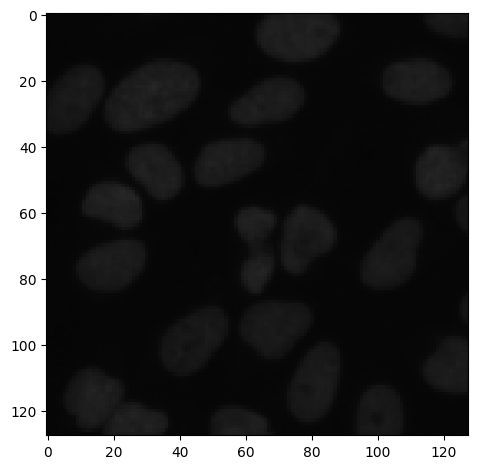

C:\Users\USER\AppData\Local\Temp\ipykernel_20676\3488435900.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(np.squeeze(Y_train[ix]))


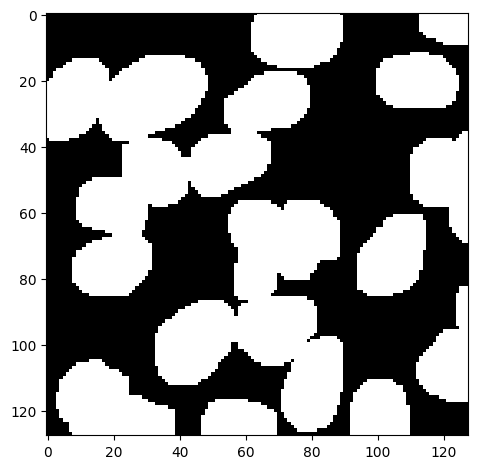

In [8]:
ix = random.randint(0, len(train_ids))
imshow(X_train[ix])
plt.show()
imshow(np.squeeze(Y_train[ix]))
plt.show()

Seems good!

# Create our Keras metric

Now we try to define the *mean average precision at different intersection over union(IoU) thresholds* metric in Keras. TensorFlow has a mean IoU metric, but it doesn't have any native support for the mean over multiple thresholds, so I tried to implement this. **I'm by no means certain that this implementation is correct, though!** Any assistance in verifying this would be most welcome!

*Update: This implementation is most definitely not correct due to the very large discrepancy between the results reported here and the LB results. It also seems to just increase over time no matter what when you train ...*

In [13]:
import keras
from keras import ops

_METRICS = [keras.metrics.MeanIoU(num_classes=2) for _ in range(10)]

In [14]:
_METRICS

[<MeanIoU name=mean_io_u>,
 <MeanIoU name=mean_io_u_1>,
 <MeanIoU name=mean_io_u_2>,
 <MeanIoU name=mean_io_u_3>,
 <MeanIoU name=mean_io_u_4>,
 <MeanIoU name=mean_io_u_5>,
 <MeanIoU name=mean_io_u_6>,
 <MeanIoU name=mean_io_u_7>,
 <MeanIoU name=mean_io_u_8>,
 <MeanIoU name=mean_io_u_9>]

In [15]:
def mean_iou(y_true, y_pred):
    # prec = []
    # for t in np.arange(0.5, 1.0, 0.05):
    #     y_pred_ = tf.to_int32(y_pred > t)
    #     score, up_opt = tf.metrics.mean_iou(y_true, y_pred_, 2)
    #     K.get_session().run(tf.local_variables_initializer())
    #     with tf.control_dependencies([up_opt]):
    #         score = tf.identity(score)
    #     prec.append(score)
    # return K.mean(K.stack(prec), axis=0)
    prec = []
    for m, t in zip(_METRICS, np.arange(0.5, 1.0, 0.05)):
        m.reset_state()
        m.update_state(y_true, tf.cast(y_pred > t, tf.int32))
        prec.append(m.result())
    return ops.mean(ops.stack(prec), axis=0)

# Build and train our neural network

Next we build our U-Net model, loosely based on [U-Net: Convolutional Networks for Biomedical Image Segmentation](https://arxiv.org/pdf/1505.04597.pdf) and very similar to [this repo](https://github.com/jocicmarko/ultrasound-nerve-segmentation) from the Kaggle Ultrasound Nerve Segmentation competition.

![image](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/u-net-architecture.png)

In [17]:
inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
s = Lambda(lambda x: x / 255)(inputs)

c1 = Conv2D(16, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(s)
c1 = Dropout(0.1)(c1)
c1 = Conv2D(16, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(c1)
p1 = MaxPooling2D((2, 2))(c1)

c2 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(p1)
c2 = Dropout(0.1)(c2)
c2 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(c2)
p2 = MaxPooling2D((2, 2))(c2)

c3 = Conv2D(64, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(p2)
c3 = Dropout(0.2)(c3)
c3 = Conv2D(64, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(c3)
p3 = MaxPooling2D((2, 2))(c3)

c4 = Conv2D(128, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(p3)
c4 = Dropout(0.2)(c4)
c4 = Conv2D(128, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(c4)
p4 = MaxPooling2D(pool_size=(2, 2))(c4)

c5 = Conv2D(256, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(p4)
c5 = Dropout(0.3)(c5)
c5 = Conv2D(256, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(c5)

u6 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
u6 = concatenate([u6, c4])
c6 = Conv2D(128, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(u6)
c6 = Dropout(0.2)(c6)
c6 = Conv2D(128, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(c6)

u7 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
u7 = concatenate([u7, c3])
c7 = Conv2D(64, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(u7)
c7 = Dropout(0.2)(c7)
c7 = Conv2D(64, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(c7)

u8 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
u8 = concatenate([u8, c2])
c8 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(u8)
c8 = Dropout(0.1)(c8)
c8 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(c8)

u9 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
u9 = concatenate([u9, c1], axis=3)
c9 = Conv2D(16, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(u9)
c9 = Dropout(0.1)(c9)
c9 = Conv2D(16, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(c9)

outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)

model = Model(inputs=[inputs], outputs=[outputs])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[mean_iou])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 128, 128,  │          0 │ input_layer_1[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 128, 128,  │        448 │ lambda_1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 128, 128,  │          0 │ conv2d_19[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 128, 128,  │      2,320 │ dropout_9[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 64,    │          0 │ conv2d_20[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 64, 64,    │      4,640 │ max_pooling2d_4[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 64, 64,    │          0 │ conv2d_21[0][0]   │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 64, 64,    │      9,248 │ dropout_10[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 32,    │          0 │ conv2d_22[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 32, 32,    │     18,496 │ max_pooling2d_5[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 32, 32,    │          0 │ conv2d_23[0][0]   │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 32, 32,    │     36,928 │ dropout_11[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 16, 16,    │          0 │ conv2d_24[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 16, 16,    │     73,856 │ max_pooling2d_6[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 16, 16,    │          0 │ conv2d_25[0][0]   │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 16, 16,    │    147,584 │ dropout_12[0][0]

 Total params: 1,941,105 (7.40 MB)

 Trainable params: 1,941,105 (7.40 MB)

 Non-trainable params: 0 (0.00 B)

*Update: Changed to ELU units, added dropout.*

Next we fit the model on the training data, using a validation split of 0.1. We use a small batch size because we have so little data. I recommend using checkpointing and early stopping when training your model. I won't do it here to make things a bit more reproducible (although it's very likely that your results will be different anyway). I'll just train for 10 epochs, which takes around 10 minutes in the Kaggle kernelw ith the current parameters.

*Update: Added early stopping and checkpointing and increased to 30 epochs.*

In [18]:
earlystopper = EarlyStopping(patience=5, verbose=1)
checkpointer = ModelCheckpoint('model-dsbowl2018-1.h5', verbose=1, save_best_only=True)
results = model.fit(X_train, Y_train, validation_split=0.1, batch_size=16, epochs=50, callbacks=[earlystopper, checkpointer])

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - loss: 0.5125 - mean_iou: 0.4536
Epoch 1: val_loss improved from None to 0.51550, saving model to model-dsbowl2018-1.h5



Epoch 1: finished saving model to model-dsbowl2018-1.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 18s 293ms/step - loss: 0.3827 - mean_iou: 0.5520 - val_loss: 0.5155 - val_mean_iou: 0.6296
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - loss: 0.2255 - mean_iou: 0.7244
Epoch 2: val_loss improved from 0.51550 to 0.16622, saving model to model-dsbowl2018-1.h5



Epoch 2: finished saving model to model-dsbowl2018-1.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 299ms/step - loss: 0.2017 - mean_iou: 0.7511 - val_loss: 0.1662 - val_mean_iou: 0.7978
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - loss: 0.1630 - mean_iou: 0.8004
Epoch 3: val_loss improved from 0.16622 to 0.15748, saving model to model-dsbowl2018-1.h5



Epoch 3: finished saving model to model-dsbowl2018-1.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 226ms/step - loss: 0.1651 - mean_iou: 0.7976 - val_loss: 0.1575 - val_mean_iou: 0.7956
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - loss: 0.1694 - mean_iou: 0.7950
Epoch 4: val_loss did not improve from 0.15748
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 221ms/step - loss: 0.1674 - mean_iou: 0.7998 - val_loss: 0.1584 - val_mean_iou: 0.7928
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - loss: 0.1592 - mean_iou: 0.7988
Epoch 5: val_loss improved from 0.15748 to 0.13419, saving model to model-dsbowl2018-1.h5



Epoch 5: finished saving model to model-dsbowl2018-1.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 232ms/step - loss: 0.1498 - mean_iou: 0.8120 - val_loss: 0.1342 - val_mean_iou: 0.8396
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - loss: 0.1395 - mean_iou: 0.8372
Epoch 6: val_loss improved from 0.13419 to 0.11619, saving model to model-dsbowl2018-1.h5


...


Epoch 16: finished saving model to model-dsbowl2018-1.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 256ms/step - loss: 0.0966 - mean_iou: 0.8733 - val_loss: 0.0836 - val_mean_iou: 0.8959
Epoch 17/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - loss: 0.0976 - mean_iou: 0.8776
Epoch 17: val_loss did not improve from 0.08358
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 242ms/step - loss: 0.0970 - mean_iou: 0.8741 - val_loss: 0.0867 - val_mean_iou: 0.9035
Epoch 18/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - loss: 0.0958 - mean_iou: 0.8772
Epoch 18: val_loss did not improve from 0.08358
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 236ms/step - loss: 0.0963 - mean_iou: 0.8762 - val_loss: 0.0889 - val_mean_iou: 0.8913
Epoch 19/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - loss: 0.0935 - mean_iou: 0.8767
Epoch 19: val_loss did not improve from 0.08358
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 242ms/step - loss: 0.0962 - mean_iou: 0.8739 - val_loss: 0.0839 - val_mean_iou: 0.9033
Epoch 20/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - loss: 0.0952 


Epoch 21: finished saving model to model-dsbowl2018-1.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 245ms/step - loss: 0.0919 - mean_iou: 0.8820 - val_loss: 0.0817 - val_mean_iou: 0.8920
Epoch 22/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - loss: 0.0910 - mean_iou: 0.8800
Epoch 22: val_loss did not improve from 0.08166
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 236ms/step - loss: 0.0910 - mean_iou: 0.8801 - val_loss: 0.0827 - val_mean_iou: 0.9088
Epoch 23/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - loss: 0.0899 - mean_iou: 0.8825
Epoch 23: val_loss improved from 0.08166 to 0.08087, saving model to model-dsbowl2018-1.h5



Epoch 23: finished saving model to model-dsbowl2018-1.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 238ms/step - loss: 0.0911 - mean_iou: 0.8820 - val_loss: 0.0809 - val_mean_iou: 0.9035
Epoch 24/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - loss: 0.0857 - mean_iou: 0.8830
Epoch 24: val_loss improved from 0.08087 to 0.08056, saving model to model-dsbowl2018-1.h5



Epoch 24: finished saving model to model-dsbowl2018-1.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 254ms/step - loss: 0.0908 - mean_iou: 0.8805 - val_loss: 0.0806 - val_mean_iou: 0.8939
Epoch 25/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - loss: 0.0893 - mean_iou: 0.8832
Epoch 25: val_loss improved from 0.08056 to 0.07936, saving model to model-dsbowl2018-1.h5



Epoch 25: finished saving model to model-dsbowl2018-1.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 239ms/step - loss: 0.0870 - mean_iou: 0.8847 - val_loss: 0.0794 - val_mean_iou: 0.9021
Epoch 26/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - loss: 0.0790 - mean_iou: 0.8936
Epoch 26: val_loss did not improve from 0.07936
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 236ms/step - loss: 0.0859 - mean_iou: 0.8860 - val_loss: 0.0800 - val_mean_iou: 0.9035
Epoch 27/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - loss: 0.0851 - mean_iou: 0.8864
Epoch 27: val_loss did not improve from 0.07936
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 238ms/step - loss: 0.0850 - mean_iou: 0.8864 - val_loss: 0.0812 - val_mean_iou: 0.8974
Epoch 28/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - loss: 0.0821 - mean_iou: 0.8922
Epoch 28: val_loss did not improve from 0.07936
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 240ms/step - loss: 0.0819 - mean_iou: 0.8910 - val_loss: 0.0817 - val_mean_iou: 0.8926
Epoch 29/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - loss: 0.0828 -

All right, looks good! Loss seems to be a bit erratic, though. I'll leave it to you to improve the model architecture and parameters!

## Make predictions

Let's make predictions both on the test set, the val set and the train set (as a sanity check). Remember to load the best saved model if you've used early stopping and checkpointing.

In [22]:
model = load_model('model-dsbowl2018-1.h5', custom_objects={'mean_iou': mean_iou}, safe_mode=False)
preds_train = model.predict(X_train[:int(X_train.shape[0]*0.9)], verbose=1)
preds_val = model.predict(X_train[int(X_train.shape[0]*0.9):], verbose=1)
preds_test = model.predict(X_test, verbose=1)

preds_train_t = (preds_train > 0.5).astype(np.uint8)
preds_val_t = (preds_val > 0.5).astype(np.uint8)
preds_test_t = (preds_test > 0.5).astype(np.uint8)

preds_test_upsampled = []
for i in range(len(preds_test)):
    preds_test_upsampled.append(resize(np.squeeze(preds_test[i]), (sizes_test[i][0], sizes_test[i][1]), mode='constant', preserve_range=True))

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step 


C:\Users\USER\AppData\Local\Temp\ipykernel_20676\806180262.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(X_train[ix])


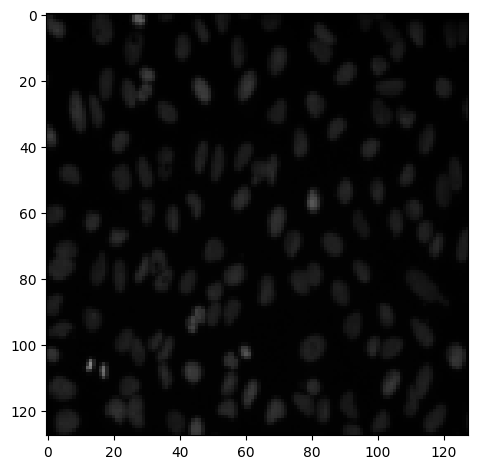

C:\Users\USER\AppData\Local\Temp\ipykernel_20676\806180262.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(np.squeeze(Y_train[ix]))


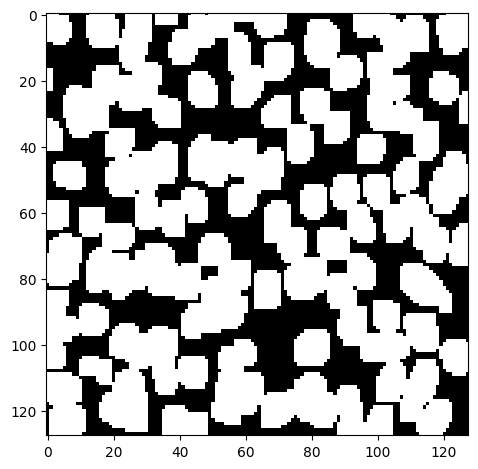

C:\Users\USER\AppData\Local\Temp\ipykernel_20676\806180262.py:6: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(np.squeeze(preds_train_t[ix]))


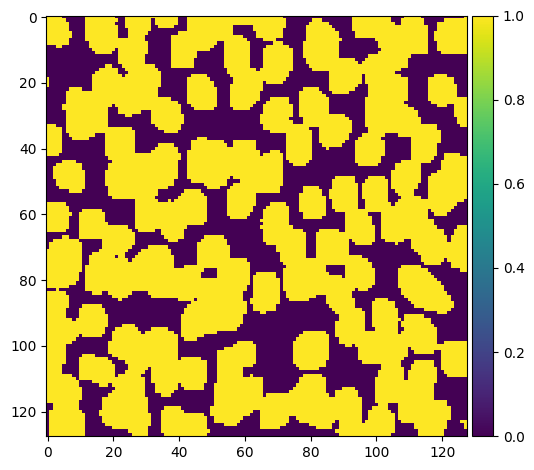

In [23]:
ix = random.randint(0, len(preds_train_t))
imshow(X_train[ix])
plt.show()
imshow(np.squeeze(Y_train[ix]))
plt.show()
imshow(np.squeeze(preds_train_t[ix]))
plt.show()

The model is at least able to fit to the training data! Certainly a lot of room for improvement even here, but a decent start. How about the validation data?

C:\Users\USER\AppData\Local\Temp\ipykernel_20676\1230725097.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(X_train[int(X_train.shape[0]*0.9):][ix])


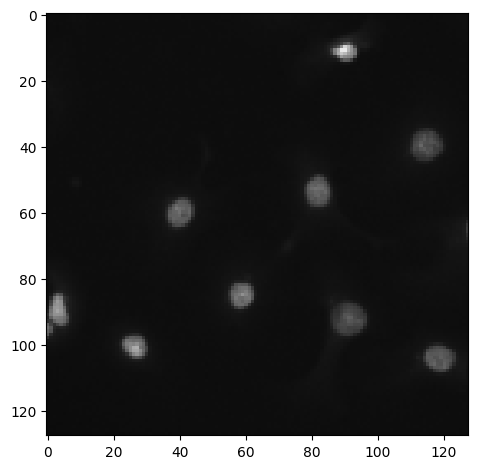

C:\Users\USER\AppData\Local\Temp\ipykernel_20676\1230725097.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(np.squeeze(Y_train[int(Y_train.shape[0]*0.9):][ix]))


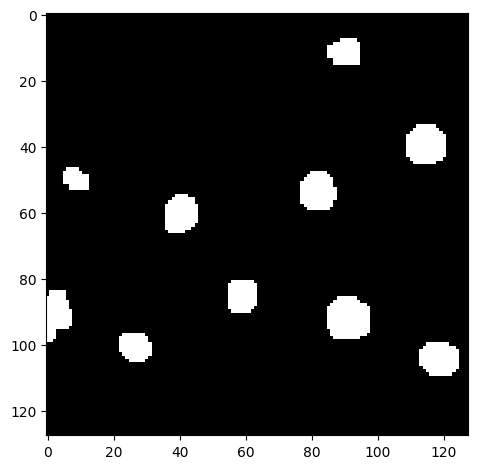

C:\Users\USER\AppData\Local\Temp\ipykernel_20676\1230725097.py:6: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(np.squeeze(preds_val_t[ix]))


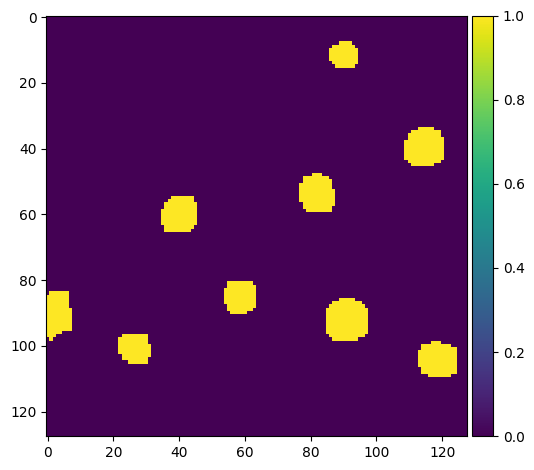

In [24]:
ix = random.randint(0, len(preds_val_t))
imshow(X_train[int(X_train.shape[0]*0.9):][ix])
plt.show()
imshow(np.squeeze(Y_train[int(Y_train.shape[0]*0.9):][ix]))
plt.show()
imshow(np.squeeze(preds_val_t[ix]))
plt.show()

Not too shabby! Definitely needs some more training and tweaking.

## Encode and submit our results

Now it's time to submit our results. I've stolen [this](https://www.kaggle.com/rakhlin/fast-run-length-encoding-python) excellent implementation of run-length encoding.

In [25]:
def rle_encoding(x):
    dots = np.where(x.T.flatten() == 1)[0]
    run_lengths = []
    prev = -2
    for b in dots:
        if (b > prev+1): run_lengths.extend((b + 1, 0))
        run_lengths[-1] += 1
        prev = b
    return run_lengths

def prob_to_rles(x, cutoff=0.5):
    lab_img = label(x > cutoff)
    for i in range(1, lab_img.max() + 1):
        yield rle_encoding(lab_img == i)

Let's iterate over the test IDs and generate run-length encodings for each separate mask identified by skimage ...

In [26]:
new_test_ids = []
rles = []
for n, id_ in enumerate(test_ids):
    rle = list(prob_to_rles(preds_test_upsampled[n]))
    rles.extend(rle)
    new_test_ids.extend([id_] * len(rle))

... and then finally create our submission!

In [ ]:
sub =